In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

import sys
sys.path.append("..")
from Src.data_modules import *

from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report,cohen_kappa_score, make_scorer, mean_squared_error, f1_score
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import cross_val_score, GridSearchCV, ParameterGrid, RandomizedSearchCV
from sklearn.utils import shuffle, resample
from sklearn.utils.class_weight import compute_class_weight
from sklearn.decomposition import PCA, NMF

from sklearn.ensemble import RandomForestClassifier

from joblib import dump, load

import statsmodels.api as sm

import shap

# Data Loading

## Train

In [ ]:
X, y, data = get_training_input_data_channel_parallel()

In [140]:
X

,std,amplitude,skewness,kurtosis,amplitude_speed,energy,psd_delta,psd_theta,psd_alpha,psd_beta,...,cov_with_others,euclidean_distance_with_others,NMF_mode_0,NMF_mode_1,NMF_mode_2,NMF_mode_3,NMF_mode_4,NMF_mode_5,NMF_mode_6,NMF_mode_7
0,7825.555520,29688.059102,1.003226,-0.184796,6907.867848,3.073489e+10,4.695744e+06,1.175634e+02,7.177495,2.692709,...,1.298848e+08,2.534439e+05,60.758658,145.524353,0.000000,0.000000,0.000000,13.183668,0.000000,0.001347
1,3451.014189,10334.807254,0.023730,-1.433863,105.911262,9.046814e+09,1.058152e+06,1.411918e+02,31.057355,3.853578,...,2.186959e+07,1.227805e+05,0.000000,0.000000,12.175418,0.000000,0.000000,0.000000,0.000000,7.269862
2,492.931099,1771.651573,-0.684970,-0.669198,65.751110,9.135565e+09,3.567960e+04,4.114712e+01,13.719510,1.860034,...,4.442941e+05,1.185094e+05,126.830619,72.440042,52.951734,39.003063,19.612547,2.806904,3.880134,8.805059
3,1464.138378,4697.576701,0.151727,-1.302688,46.265269,1.335568e+09,1.627648e+05,1.006525e+02,5.891496,2.236487,...,4.320343e+06,5.533832e+04,52.182331,42.727429,0.000000,2.397715,0.000000,2.581118,0.928183,0.000000
4,201.662656,840.036264,0.970873,-0.181173,50.397698,2.277465e+09,4.361352e+03,2.832742e+01,14.392234,3.220226,...,8.180331e+04,6.490656e+04,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
261750,25523.904669,88436.246320,0.504721,-0.976549,1073.167690,1.046961e+12,4.625256e+07,5.195211e+03,2003.536632,912.637258,...,4.207478e+07,1.158444e+06,1421.019200,1161.200942,163.915352,227.741834,84.902430,71.999322,35.089540,15.051026
261751,15533.132687,96328.259642,0.769081,1.837086,16686.128478,1.234238e+11,7.769579e+07,1.839673e+07,820728.739643,103207.215450,...,9.160130e+07,5.082711e+05,0.000000,333.676191,111.908634,175.890510,0.000000,3.540932,0.000000,10.801796
261752,2406.259828,9016.444927,-0.140763,-1.049870,933.088027,4.981932e+10,3.598111e+05,2.911543e+03,753.907998,112.963995,...,-4.650309e+06,2.925163e+05,227.313020,122.009217,155.392577,81.105960,47.122991,4.547813,7.020679,33.873587
261753,780.113399,3606.611050,-1.082377,0.398272,1134.092094,1.204014e+11,4.392477e+04,1.681617e+03,465.510352,139.444653,...,-1.922934e+05,4.426558e+05,434.341827,254.082029,202.135559,131.491897,69.301414,11.415496,12.692468,39.133730


In [14]:
X.to_csv("X_data_inter.csv", index=False, sep=",")
y.to_csv("y_data_inter.csv", index=False, sep=",")

In [2]:
X = pd.read_csv("X_data_inter.csv", sep=",")
y = pd.read_csv("y_data_inter.csv", sep=",")

In [146]:
# 1. Charger et prétraiter les données
X_train, X_test, y_train, y_test = train_test_split(X_boot, y_boot, test_size=0.3, random_state=42)

### NMF

In [36]:
all_windows = np.array(data["signal_windowed"].tolist())
all_windows = [[x if x >= 0 else 0 for x in arr] for arr in all_windows]

1
2
3
4
5
6
7
8
9


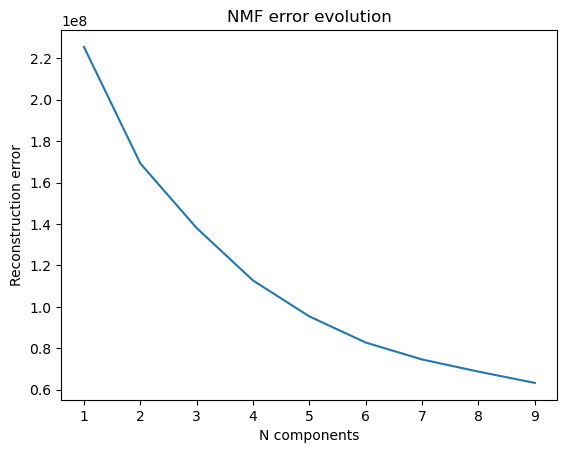

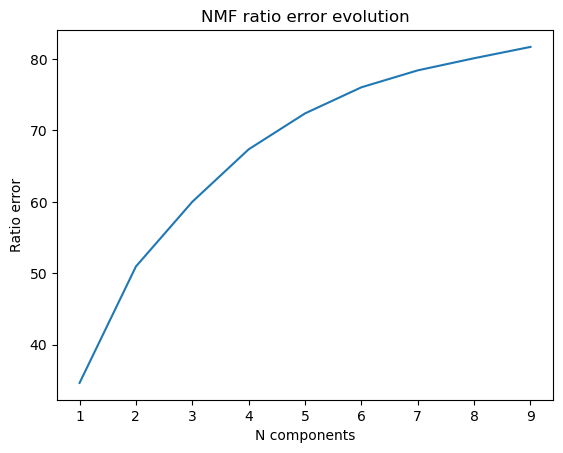

In [37]:
n_range = 10
errors = []
ratios = []

for n in range(1, n_range):
    print(n)
    model = NMF(n_components=n, init='random', random_state=42)
    model.fit_transform(all_windows)
    # Erreur de reconstruction
    reconstruction_error = model.reconstruction_err_

    # Norme Frobenius de la matrice originale
    original_norm = np.linalg.norm(all_windows, ord='fro')

    # Ratio de reconstruction
    reconstruction_ratio = (1 - (reconstruction_error / original_norm))*100

    errors += [reconstruction_error]
    ratios += [reconstruction_ratio]

plt.plot(errors)
plt.xticks(ticks=[i for i in range(n_range - 1)], labels=[i for i in range(1, n_range)])
plt.xlabel("N components")
plt.ylabel("Reconstruction error")
plt.title("NMF error evolution")
plt.show()

plt.plot(ratios)
plt.xticks(ticks=[i for i in range(n_range - 1)], labels=[i for i in range(1, n_range)])
plt.xlabel("N components")
plt.ylabel("Ratio error")
plt.title("NMF ratio error evolution")
plt.show()

In [38]:
# Initialiser un modèle NMF
n_components = 8  # Nombre de composantes latentes
model = NMF(n_components=n_components, init='random', random_state=42)

# Ajuster le modèle sur les données
W = model.fit_transform(all_windows)  # Matrice W (caractéristiques latentes)
H = model.components_ # Matrice H (poids des caractéristiques)

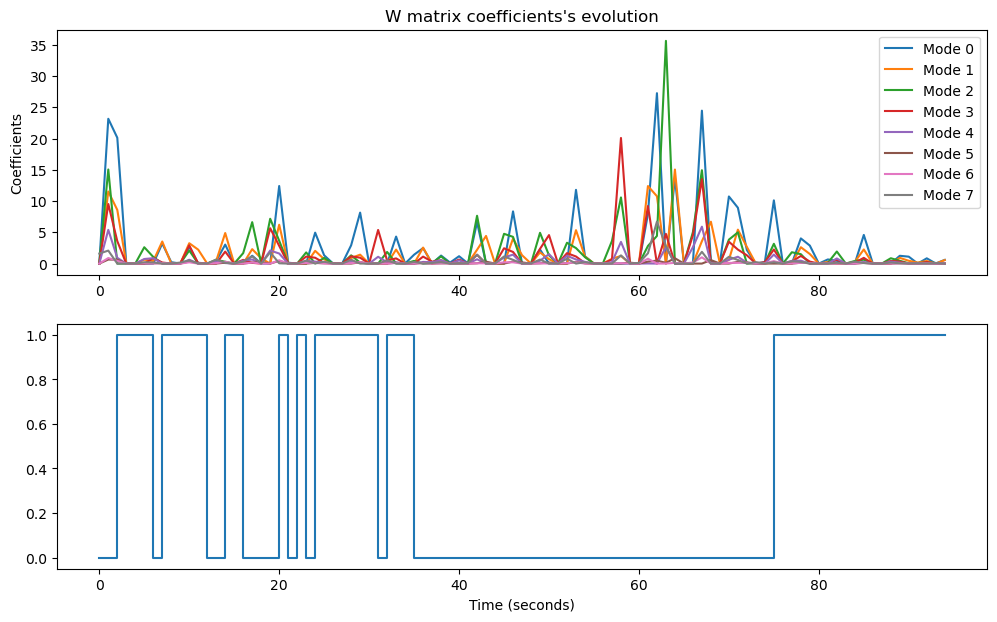

In [39]:
fig, axs = plt.subplots(2,1, figsize=(12,7))

axs[0].plot(W[5:100])
axs[0].set_ylabel("Coefficients")
axs[0].set_title("W matrix coefficients's evolution")
axs[0].legend(["Mode {}".format(i) for i in range(n_components)])

_, target_data = load_train_data(set=0)
axs[1].step(range(len(target_data[0][5:100])), target_data[0][5:100])
axs[1].set_xlabel("Time (seconds)")

plt.show()

## Test

In [4]:
test_df = get_testing_input_data_channel_parallel()

Processing channel n°0
Processing channel n°1
Processing channel n°2
Processing channel n°3
Processing channel n°4
112615 windows to compute...


Parallel feature extraction: 100%|██████████| 112615/112615 [05:50<00:00, 321.52it/s]


In [5]:
test_df.to_csv("test_df_inter.csv", index=False, sep=",")

In [8]:
# Mélanger les données X et les labels y
X_shuffled, y_shuffled = shuffle(X_boot, y_boot, random_state=42)

In [7]:
test_df

,std,amplitude,skewness,kurtosis,amplitude_speed,energy,psd_delta,psd_theta,psd_alpha,psd_beta,...,me,apen,mte,zc,wv1,wv4,NMF_mode_0,NMF_mode_1,NMF_mode_2,NMF_mode_3
0,305563.566219,1.293642e+06,0.434145,-0.754239,269420.758627,5.537106e+13,6.334961e+09,2.823793e+07,4.073779e+06,2.827987e+05,...,1.107421e+11,0.002006,9.265939e+08,1.0,1.562293e+08,3.402823e+38,0.000000,1370.853466,0.000000,2925.750682
1,166275.029007,5.420851e+05,0.189727,-1.307648,23212.059563,1.114053e+14,5.407313e+09,2.711170e+07,1.331249e+06,5.350971e+04,...,2.228105e+11,0.002006,1.864113e+08,0.0,7.608328e+07,2.371816e+37,0.000000,0.000000,0.000000,0.000000
2,168869.992027,5.490227e+05,-0.683280,-0.856411,4593.129876,4.643931e+13,2.242951e+09,2.481536e+04,6.026740e+02,7.699055e+01,...,9.287862e+10,0.002006,5.978899e+08,1.0,5.304422e+07,4.534964e+37,5214.354153,1339.116488,2355.438735,0.000000
3,126961.292996,4.112532e+05,-0.286073,-1.238278,3364.150882,4.004503e+13,1.253346e+09,1.249033e+04,5.102626e+02,8.241096e+01,...,8.009006e+10,0.002006,3.390113e+08,0.0,2.325113e+07,7.003614e+35,3141.790648,2195.981694,257.674743,1911.745554
4,77381.358953,2.566060e+05,0.659431,-0.863531,3412.434631,1.560383e+13,4.591600e+08,5.085573e+03,3.149136e+02,5.173688e+01,...,3.120765e+10,0.002006,1.318833e+08,1.0,1.094578e+07,7.613116e+34,0.000000,0.000000,0.000000,4.544156
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
112610,151.369836,7.154611e+02,-0.052191,-0.651129,400.478870,1.476659e+07,1.415253e+03,1.970286e+01,1.921482e+02,9.356871e+00,...,2.953318e+04,0.000772,2.195137e+04,131.0,1.252187e+02,1.193592e+14,0.648686,0.000000,0.369965,0.000604
112611,9971.037979,5.142117e+04,1.302222,2.498350,4050.110702,5.054372e+10,3.297339e+07,1.657559e+06,3.502535e+04,4.813835e+03,...,1.010874e+08,0.002006,1.099486e+06,65.0,7.902190e+05,1.355560e+30,169.198268,0.000000,0.000000,0.223149
112612,10235.685494,1.207256e+05,6.827926,57.484353,51503.674741,5.288791e+10,1.264055e+07,7.165865e+06,4.572163e+06,1.934842e+06,...,1.057758e+08,0.002006,1.565598e+07,9.0,8.901765e+05,8.417408e+27,0.000000,54.049253,16.683617,0.000000
112613,1916.322929,6.946794e+03,-0.554792,-0.774415,369.217238,4.404837e+09,3.326009e+05,3.553052e+02,6.156241e+01,1.966540e+01,...,8.809675e+06,0.002006,6.470904e+04,3.0,6.784100e+03,7.212464e+21,25.941413,28.283335,0.000000,17.385969


# Variables selection

In [153]:
df = pd.concat([X,y], axis=1)

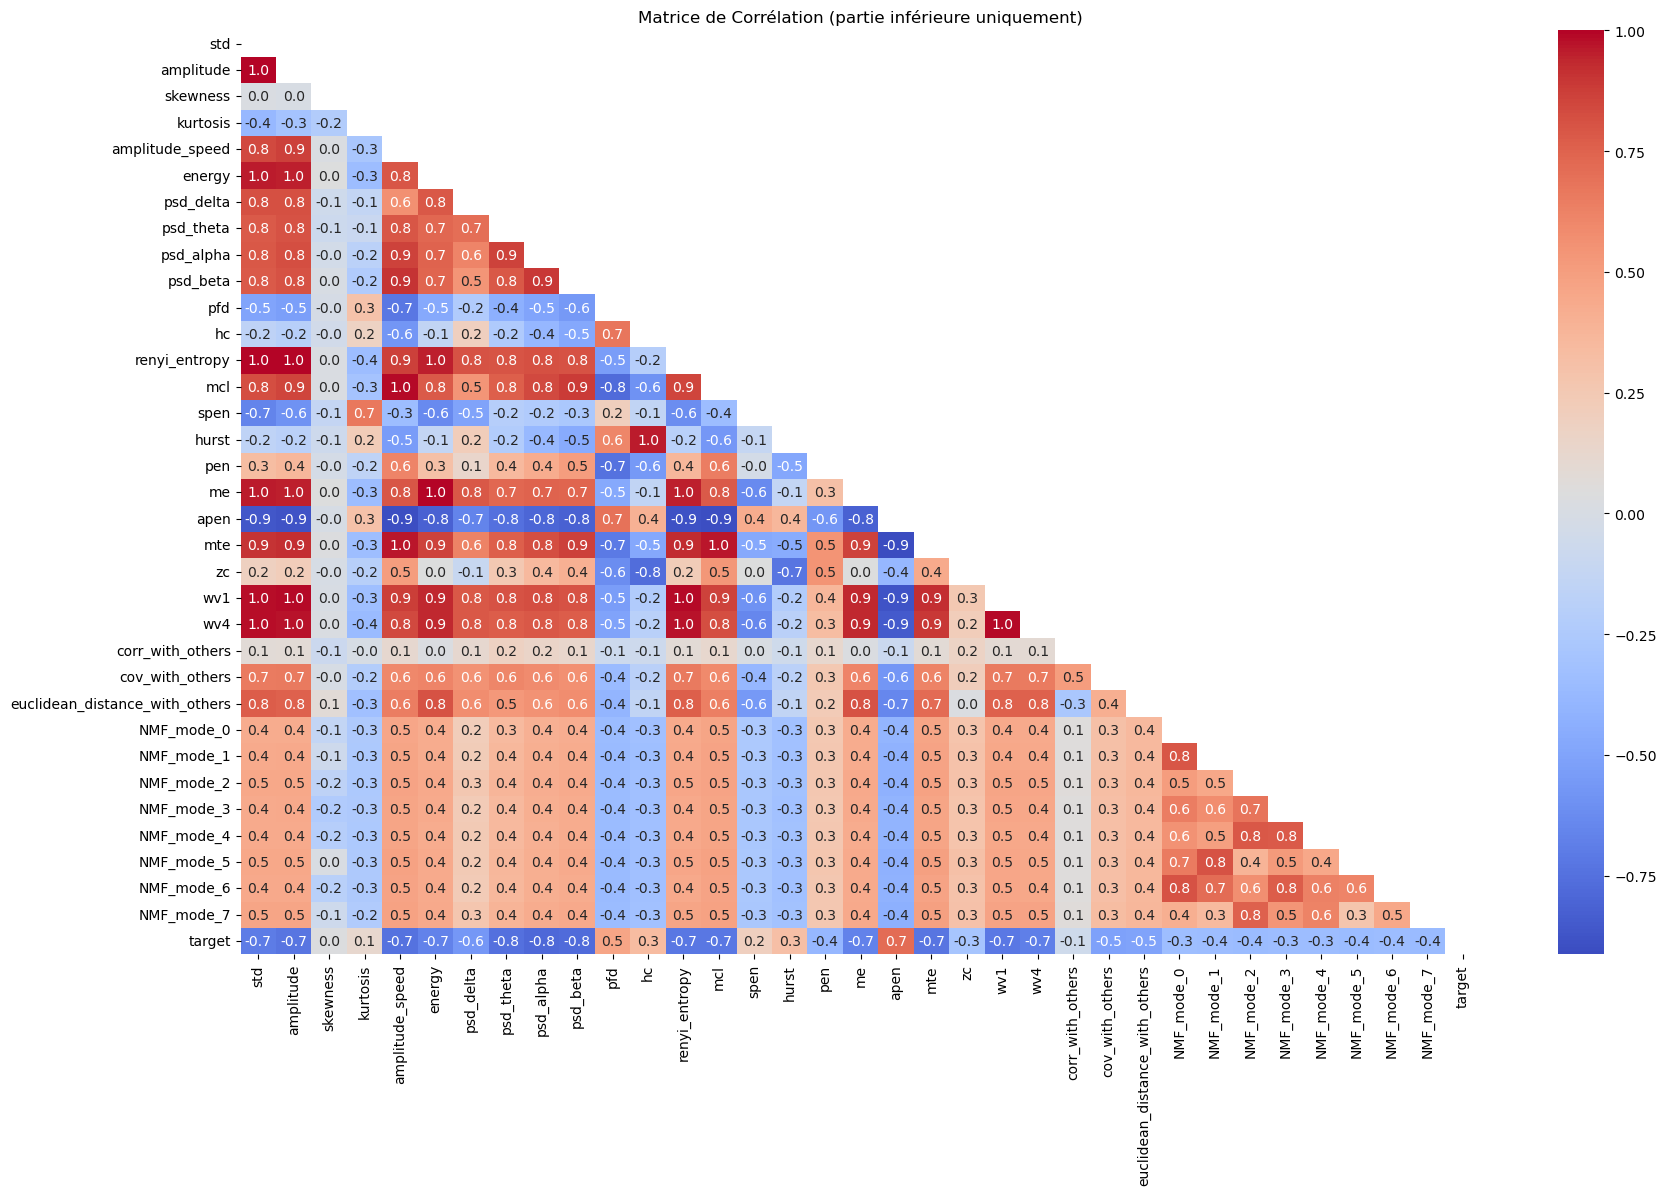

In [154]:
# Calcul de la matrice de corrélation
correlation_matrix = df.corr(method="spearman")

# Créer un masque pour cacher la partie supérieure
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))

# Affichage avec une heatmap
plt.figure(figsize=(20, 12))
sns.heatmap(correlation_matrix, mask=mask, annot=True, cmap='coolwarm', fmt='.1f')
plt.title("Matrice de Corrélation (partie inférieure uniquement)")
plt.show()

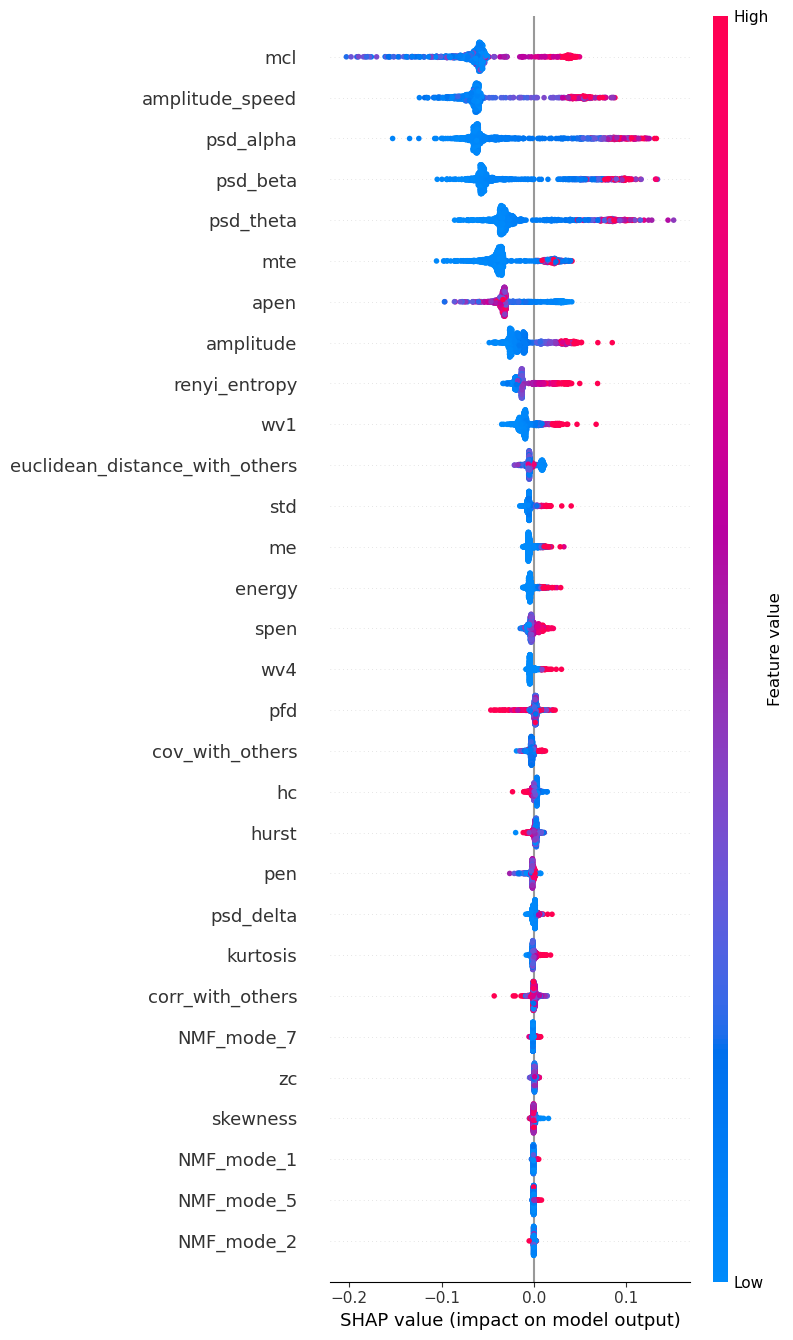

In [157]:
model = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10, n_jobs=-1)
model.fit(X, y)

# Créer un explainer pour le modèle
explainer = shap.TreeExplainer(model, approximate=True)

# Calculer les valeurs SHAP pour un sous-ensemble des données
shap_values = explainer.shap_values(X[:1000])

# Résumé pour toutes les données
shap.summary_plot(shap_values[:,:,0], X[:1000], feature_names=X.columns.tolist(), max_display=30)

# Data augmentation

In [7]:
# Bootstrap : tirer un échantillon avec remplacement
bootstrap_sample_X = resample(X, n_samples=40000, replace=True)
bootstrap_sample_y = resample(y, n_samples=40000, replace=True)

X_boot = pd.concat([X, bootstrap_sample_X], axis=0)
y_boot = pd.concat([y, bootstrap_sample_y], axis=0)


# Model

In [30]:
class_weights = compute_class_weight('balanced', classes=np.unique(y), y=y)
class_weight_dict = {0: class_weights[0], 1: class_weights[1]}

In [132]:
# Initialiser le modèle Random Forest
rf = RandomForestClassifier(n_estimators=200, random_state=42, max_depth=10, n_jobs=-1)

# Entraîner le modèle
rf.fit(X_shuffled, y_shuffled)

RandomForestClassifier(max_depth=10, n_estimators=200, n_jobs=-1,
                       random_state=42)

In [30]:
y_pred = rf.predict(X_test).tolist()  # Pour une classification binaire
y_pred_train = rf.predict(X_train).tolist()

# Évaluation du modèle
print("Train Accuracy:", accuracy_score(y_train, y_pred_train))
print("Test Accuracy:", accuracy_score(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))

# Calcul du coefficient de Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)

print(f"Score Kappa : {kappa_score}")

Train Accuracy: 0.9025129244228984
Test Accuracy: 0.8973676361748428

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.87      0.87     36419
           1       0.91      0.92      0.91     54108

    accuracy                           0.90     90527
   macro avg       0.89      0.89      0.89     90527
weighted avg       0.90      0.90      0.90     90527

Score Kappa : 0.7864824314256433


## Results

#### Résultats de Modèle (n_estimators=400, max_depth=30)

Précision sur l'entraînement
**Train Accuracy**: 1.0
**Test Accuracy**: 0.9539012059546398

Rapport de Classification
| Classe | Précision | Rappel | F1-Score | Support |
|--------|-----------|--------|----------|---------|
| 0      | 0.94      | 0.95   | 0.94     | 31485   |
| 1      | 0.96      | 0.96   | 0.96     | 47042   |

**Exactitude globale (accuracy)**: 0.95  
**Moyenne macro (macro avg)**: 0.95 (Précision), 0.95 (Rappel), 0.95 (F1-Score)  
**Moyenne pondérée (weighted avg)**: 0.95 (Précision), 0.95 (Rappel), 0.95 (F1-Score)

Score Kappa
**Score Kappa**: <span style="color:red">0.9041246709971473</span>

#### Résultats du modèle (n_estimators=300, max_depth=30)

Précision sur les ensembles
- **Train Accuracy**: 1.0  
- **Test Accuracy**: 0.9536  

Rapport de classification
| Classe | Précision | Rappel | F1-Score | Support |
|--------|-----------|--------|----------|---------|
| 0      | 0.94      | 0.95   | 0.94     | 31,485  |
| 1      | 0.96      | 0.96   | 0.96     | 47,042  |

| Métrique        | Valeur |
|------------------|--------|
| **Exactitude**   | 0.95   |
| **Macro Moyenne**| 0.95   |
| **Moyenne Pondérée** | 0.95   |

Score Kappa
- **Score Kappa**: 0.9035

#### Model Performance (n_estimators=200, max_depth=50)

Train Accuracy
- **Train Accuracy:** 1.0
- **Test Accuracy:** 0.9533281546474461

Classification Report
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 0.94      | 0.95   | 0.94     | 31,485  |
| 1     | 0.96      | 0.96   | 0.96     | 47,042  |

| Metric       | Value |
|--------------|-------|
| Accuracy     | 0.95  |
| Macro Avg    | 0.95  |
| Weighted Avg | 0.95  |

Score Kappa
- **Score Kappa:** 0.9029476181891937

#### Model Performance (n_estimators=300, max_depth=50)

Train Accuracy
- **Train Accuracy:** 1.0
- **Test Accuracy:** 0.9534937028028576

Classification Report
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 0.94      | 0.95   | 0.94     | 31,485  |
| 1     | 0.96      | 0.96   | 0.96     | 47,042  |

| Metric       | Value |
|--------------|-------|
| Accuracy     | 0.95  |
| Macro Avg    | 0.95  |
| Weighted Avg | 0.95  |

Score Kappa
- **Score Kappa:** 0.9032913621291838


#### Model Performance (n_estimators=300, max_depth=20)

Train Accuracy
- **Train Accuracy:** 0.9958739930578296
- **Test Accuracy:** 0.9530989341245686

Classification Report
| Class | Precision | Recall | F1-Score | Support |
|-------|-----------|--------|----------|---------|
| 0     | 0.94      | 0.94   | 0.94     | 31,485  |
| 1     | 0.96      | 0.96   | 0.96     | 47,042  |

| Metric       | Value |
|--------------|-------|
| Accuracy     | 0.95  |
| Macro Avg    | 0.95  |
| Weighted Avg | 0.95  |

Score Kappa
- **Score Kappa:** 0.902470962562292

## Gridsearch

In [ ]:
# Définir les hyperparamètres à tester
param_grid = {
    'max_depth': [10, 20, 30, 40, 50, 70, 100, None],            # Profondeur maximale des arbres
    'n_estimators': [50, 100, 200, 250, 300]              # Nombre d'arbres dans la forêt
}

# Créer le modèle de Random Forest
rf = RandomForestClassifier(random_state=42)

# Définir GridSearchCV avec Cross-Validation (par défaut, k=5)
grid_search = GridSearchCV(estimator=rf, param_grid=param_grid, cv=5, verbose=2, n_jobs=-1)

# Lancer la recherche des meilleurs hyperparamètres
grid_search.fit(X_train, y_train)

# Résultats
print(f"Meilleurs paramètres : {grid_search.best_params_}")
print(f"Meilleur score : {grid_search.best_score_}")

# Tester sur le jeu de test
y_pred = grid_search.best_estimator_.predict(X_test)
print(f"Précision sur le jeu de test : {accuracy_score(y_test, y_pred)}")

# Calcul du coefficient de Kappa
kappa_score = cohen_kappa_score(y_test, y_pred)
print(f"Score Kappa : {kappa_score}")

# OLS

In [152]:
# Ajouter une constante (biais) à X (important pour l'OLS)
X_cst = sm.add_constant(X_train.reset_index(drop=True))

# Régression OLS
model = sm.OLS(y_train.reset_index(drop=True), X_cst)  # Y est la variable cible, X les caractéristiques (avec constante)
results = model.fit()  # Ajuster le modèle

# Afficher le résumé des statistiques du modèle
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                      -1.492
Model:                            OLS   Adj. R-squared:                 -1.492
Method:                 Least Squares   F-statistic:                       nan
Date:                Fri, 10 Jan 2025   Prob (F-statistic):                nan
Time:                        15:37:14   Log-Likelihood:            -2.4553e+05
No. Observations:              211228   AIC:                         4.911e+05
Df Residuals:                  211227   BIC:                         4.911e+05
Df Model:                           0                                         
Covariance Type:            nonrobust                                         
                                     coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------------------------------------------
const       

In [4]:
# Ajouter une constante (biais) à X (important pour l'OLS)
X_cst = sm.add_constant(X_train)

# Régression OLS
model = sm.OLS(y_train, X_cst)  # Y est la variable cible, X les caractéristiques (avec constante)
results = model.fit()  # Ajuster le modèle

# Afficher le résumé des statistiques du modèle
print(results.summary())

                            OLS Regression Results                            
Dep. Variable:                 target   R-squared:                       0.057
Model:                            OLS   Adj. R-squared:                  0.057
Method:                 Least Squares   F-statistic:                     740.0
Date:                Wed, 08 Jan 2025   Prob (F-statistic):               0.00
Time:                        18:18:13   Log-Likelihood:            -1.2407e+05
No. Observations:              183228   AIC:                         2.482e+05
Df Residuals:                  183212   BIC:                         2.483e+05
Df Model:                          15                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const          0.6185      0.001    516.128      0.0

# Submission

In [133]:
def format_array_to_target_format(array, record_number, nb_points):

    formatted_target = []
    for i in range(5):
        channel_encoding = (i + 1) * 100000
        record_number_encoding = record_number * 1000000
        for j in range(nb_points):
            formatted_target.append(
                {
                    "identifier": record_number_encoding + channel_encoding + j,
                    "target": array[i][j],
                }
            )
    return formatted_target

In [135]:
set_4_df = pd.DataFrame()
size_channel_set_4 = 13204

set_5_df = pd.DataFrame()
size_channel_set_5 = 9319

set_4_idx = 0
set_5_idx = size_channel_set_4

for c in range(5):
    #print(test_df[set_4_idx:set_4_idx+size_channel_set_4])
    set_4_df = pd.concat([set_4_df, test_df[set_4_idx:set_4_idx+size_channel_set_4]])

    #print(test_df[set_5_idx:set_5_idx+size_channel_set_5])
    set_5_df = pd.concat([set_5_df, test_df[set_5_idx:set_5_idx+size_channel_set_5]])

    set_4_idx += size_channel_set_4 + size_channel_set_5
    set_5_idx += size_channel_set_4 + size_channel_set_5

new_test_df = pd.concat([set_4_df, set_5_df])
new_test_df.reset_index(drop=True, inplace=True)

In [137]:
results = []

# Set 4
X_test_4 = new_test_df[:66020]
preds = rf.predict(X_test_4)
sublists = [preds[i:i + 13204] for i in range(0, len(preds), 13204)]

formatted_preds = format_array_to_target_format(sublists, 4, 13204)
results.extend(formatted_preds)

# Set 5
X_test_5 = new_test_df[66020:]
preds = rf.predict(X_test_5)
sublists = [preds[i:i + 9319] for i in range(0, len(preds), 9319)]

formatted_preds = format_array_to_target_format(sublists, 5, 9319)
results.extend(formatted_preds)

df_results = pd.DataFrame(results)
df_results.to_csv("../Results/my_submission_RandomForest_nmf_nest_200_mdepth_10_all_variables_and_channels.csv", index = False)

In [138]:
df_results["target"].value_counts()

target
0    66310
1    46305
Name: count, dtype: int64